In [12]:
import numpy as np
import matplotlib.pyplot as plt

def bifurcationlite(a, b, e, *,
                    b_xlim=(-2, 3),
                    a_ylim=(-1.5, 1.5),
                    n_sn=400,
                    n_h=600,
                    point_kwargs=None,
                    ax=None,
                    show=True):
    """
    Plot FHN (b,a)-plane bifurcation curves (SN and Hopf) for epsilon=e,
    and mark the given point (b,a).

    Returns (fig, ax).
    """

    def safe_sqrt(x):
        return np.sqrt(np.maximum(x, 0.0))

    # SN curve (as in your code). Defined for b>1 and b<0.
    def a_SN(b_arr):
        return (2.0/3.0) * (1.0 - b_arr) * safe_sqrt((b_arr - 1.0)/(3.0*b_arr))

    # Hopf curve (as in your code). Requires 1 - e*b >= 0.
    def a_H(b_arr):
        return (1.0/3.0) * (e*b_arr**2 + 2.0*b_arr - 3.0) * safe_sqrt((1.0 - e*b_arr)/3.0)

    # ---- build b grids ----
    bmin, bmax = b_xlim

    # avoid singularities at b=1 and b=0
    b_SN1 = np.linspace(max(1.001, bmin), bmax, n_sn) if bmax > 1.001 else np.array([])
    b_SN2 = np.linspace(bmin, min(-0.001, bmax), n_sn) if bmin < -0.001 else np.array([])

    b_H = np.linspace(bmin, bmax, n_h)
    b_H_valid = b_H[(1.0 - e*b_H) >= 0.0]  # ensures sqrt argument nonnegative

    # ---- compute curves ----
    SN1 = a_SN(b_SN1) if b_SN1.size else None
    SN2 = a_SN(b_SN2) if b_SN2.size else None
    H   = a_H(b_H_valid) if b_H_valid.size else None

    # ---- axis setup ----
    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 6))
        created_fig = True
    else:
        fig = ax.figure

    # ---- plot SN ----
    if b_SN1.size:
        ax.plot(b_SN1,  SN1,  'b',  label='SN (+)')
        ax.plot(b_SN1, -SN1,  'b--')
    if b_SN2.size:
        ax.plot(b_SN2,  SN2,  color='orange', label='SN (- region)')
        ax.plot(b_SN2, -SN2,  color='orange', linestyle='--')

    # ---- plot Hopf ----
    if b_H_valid.size:
        ax.plot(b_H_valid,  H,  'g',  label='Hopf (+)')
        ax.plot(b_H_valid, -H,  'g--')

    # ---- mark the point ----
    if point_kwargs is None:
        point_kwargs = dict(marker='o', ms=8, color='crimson')
    ax.plot([b], [a], **point_kwargs, label=f'point (b={b:g}, a={a:g})')

    # ---- cosmetics ----
    ax.axhline(0, color='k', lw=0.8)
    ax.axvline(0, color='k', lw=0.8)
    ax.set_xlim(*b_xlim)
    ax.set_ylim(*a_ylim)
    ax.set_xlabel('b')
    ax.set_ylabel('a')
    ax.set_title(f'FHN Bifurcation Diagram (ε = {e:g})')
    ax.grid(True, alpha=0.3)
    ax.legend()

    if show and created_fig:
        plt.show()

    return fig, ax

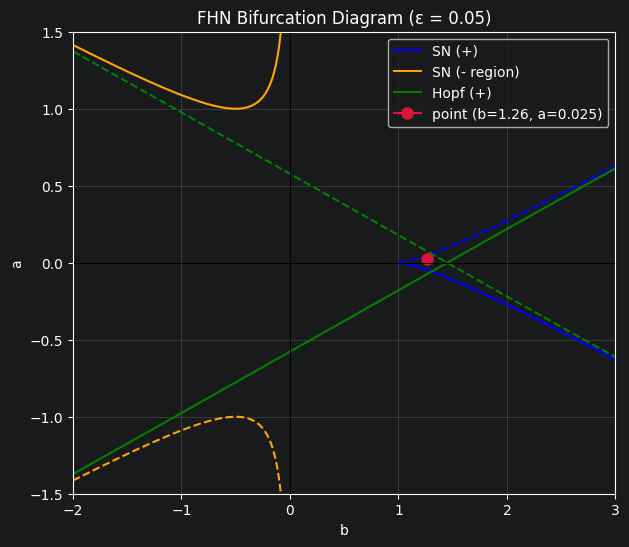

In [15]:
fig, ax = bifurcationlite(a=0.025, b=1.26, e=0.05)

fig.savefig("bifurcation.png", dpi=300, bbox_inches="tight")

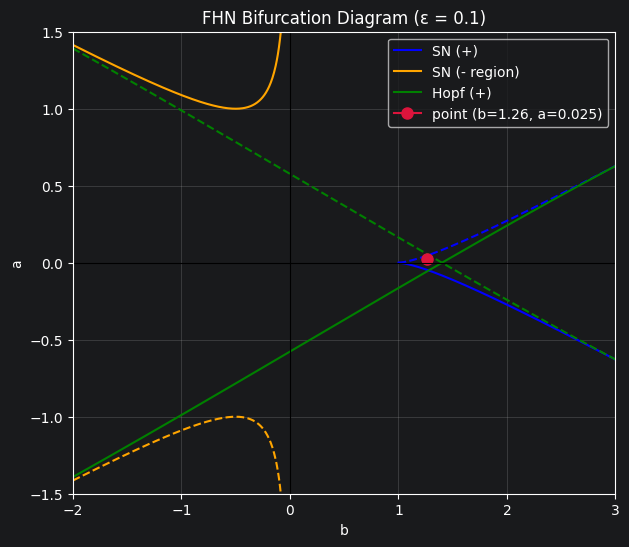

In [16]:
fig, ax = bifurcationlite(a=0.025, b=1.26, e=0.1)

fig.savefig("bifurcation.png", dpi=300, bbox_inches="tight")


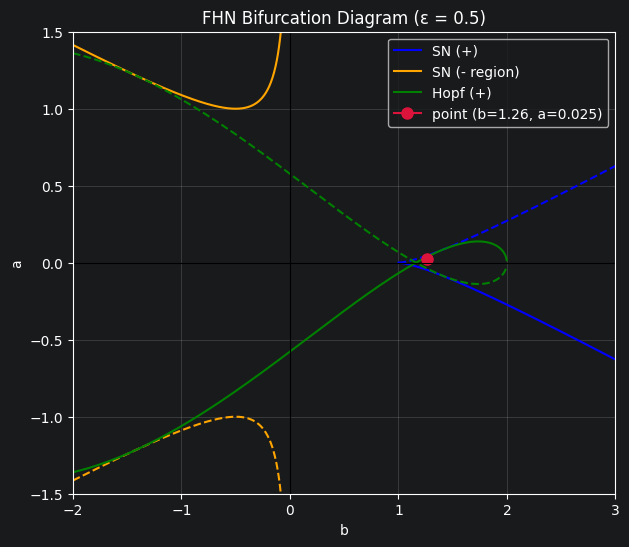

In [13]:
fig, ax = bifurcationlite(a=0.025, b=1.26, e=0.5)

fig.savefig("bifurcation.png", dpi=300, bbox_inches="tight")

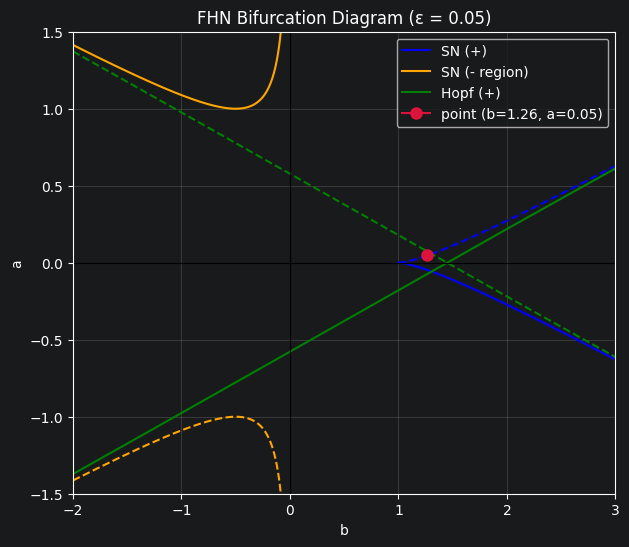

In [14]:
fig, ax = bifurcationlite(a=0.05, b=1.26, e=0.05)

fig.savefig("bifurcation.png", dpi=300, bbox_inches="tight")

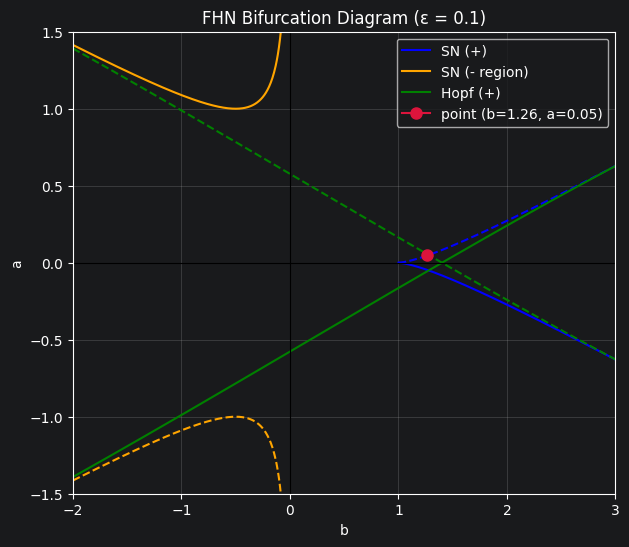

In [17]:
fig, ax = bifurcationlite(a=0.05, b=1.26, e=0.1)

fig.savefig("bifurcation.png", dpi=300, bbox_inches="tight")

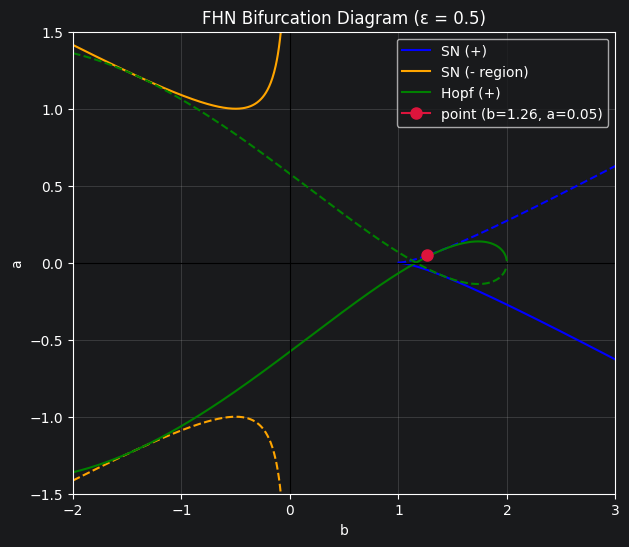

In [18]:
fig, ax = bifurcationlite(a=0.05, b=1.26, e=0.5)

fig.savefig("bifurcation.png", dpi=300, bbox_inches="tight")

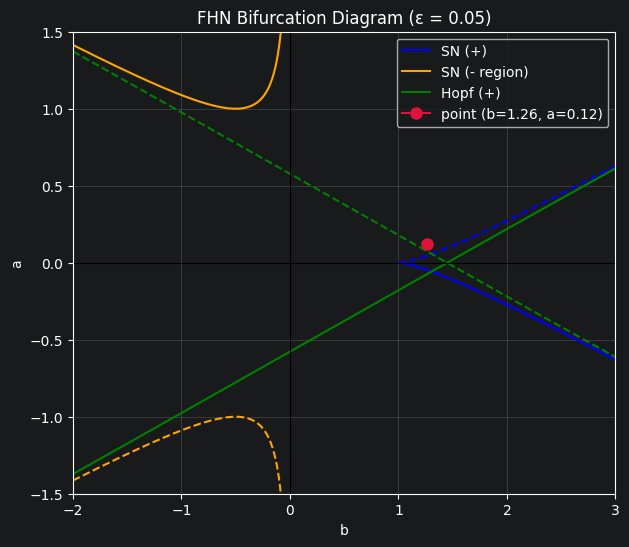

In [19]:
fig, ax = bifurcationlite(a=0.12, b=1.26, e=0.05)

fig.savefig("bifurcation.png", dpi=300, bbox_inches="tight")

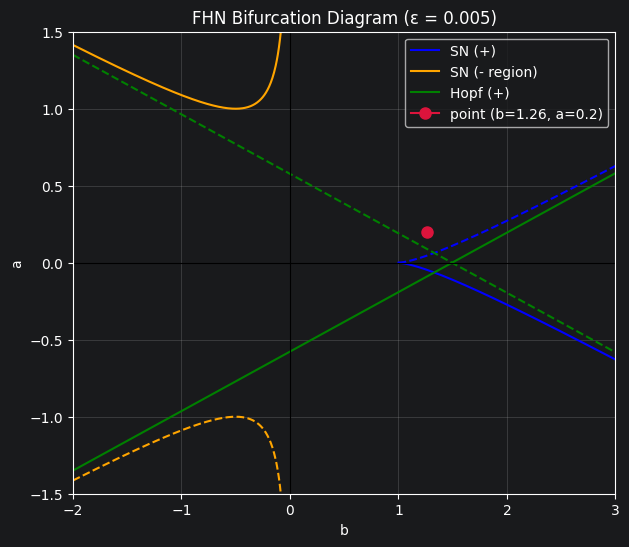

In [25]:
fig, ax = bifurcationlite(a=0.20, b=1.26, e=0.005)

fig.savefig("bifurcation.png", dpi=300, bbox_inches="tight")

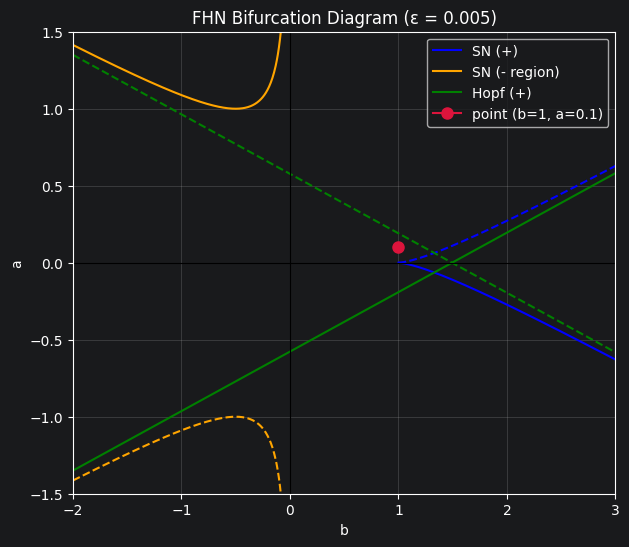

In [33]:
fig, ax = bifurcationlite(a=0.1, b=1.0, e=0.005)

fig.savefig("bifurcation.png", dpi=300, bbox_inches="tight")

In [38]:
import numpy as np
import plotly.io as pio
pio.renderers.default = "browser"

# ====== 网格范围（自己改）======
xmin, xmax, nx = -5, 5, 401
ymin, ymax, ny = -5, 5, 401

x = np.linspace(xmin, xmax, nx)
y = np.linspace(ymin, ymax, ny)
X, Y = np.meshgrid(x, y)

# ====== 复根号（允许判别式为负）======
disc = X**2 - 4*Y
root = np.sqrt(disc.astype(np.complex128))

lam_p = X + root
lam_m = X - root

Re_p = np.real(lam_p)
Re_m = np.real(lam_m)

# 你要的：max real branch
sigma = np.maximum(Re_p, Re_m)

# ====== 交互式 3D 曲面 ======
fig = go.Figure(data=[
    go.Surface(
        x=X, y=Y, z=sigma,
        colorbar=dict(title="sigma"),
        hovertemplate="x=%{x:.3f}<br>y=%{y:.3f}<br>sigma=%{z:.3f}<extra></extra>"
    )
])

fig.update_layout(
    title="Interactive 3D: σ(x,y)=max(Re(x±sqrt(x^2-4y)))",
    scene=dict(
        xaxis_title="x",
        yaxis_title="y",
        zaxis_title="sigma"
    )
)

fig.show(renderer="browser")

Error: could not locate runnable browser

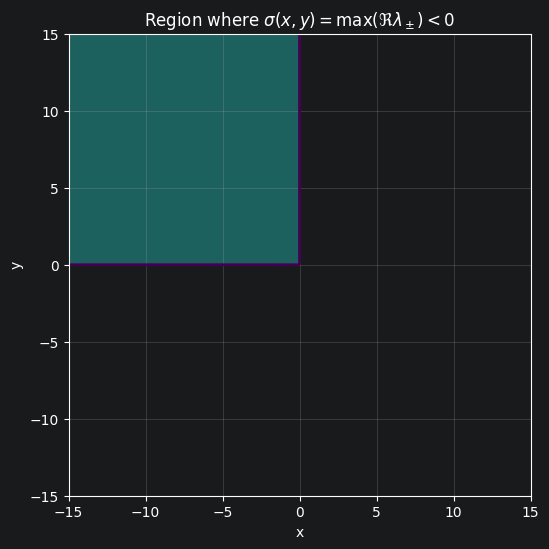

In [41]:
import numpy as np
import matplotlib.pyplot as plt

# ====== 1) 网格范围（改这里）======
xmin, xmax, nx = -15, 15, 1200
ymin, ymax, ny = -15, 15, 1200

x = np.linspace(xmin, xmax, nx)
y = np.linspace(ymin, ymax, ny)
X, Y = np.meshgrid(x, y)

# ====== 2) 定义 sigma(x,y) = max Re(lambda±) ======
disc = X**2 - 4*Y
root = np.sqrt(disc.astype(np.complex128))   # 允许根号为虚

lam_p = X + root
lam_m = X - root
sigma = np.maximum(np.real(lam_p), np.real(lam_m))  # 让函数自己判断谁更大

# ====== 3) 负区域 mask：sigma < 0 ======
neg = (sigma < 0)

# ====== 4) 绘图：负区域填色 + sigma=0 边界 ======
fig, ax = plt.subplots(figsize=(7, 6))

# 填色显示 sigma<0 区域
ax.contourf(X, Y, neg.astype(int), levels=[0.5, 1.5], alpha=0.6)

# 画 sigma=0 的等值线（边界）
ax.contour(X, Y, sigma, levels=[0], linewidths=2)

ax.set_title(r"Region where $\sigma(x,y)=\max(\Re\lambda_\pm)<0$")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal", adjustable="box")
ax.grid(True, alpha=0.3)

plt.show()